# Customer Purchase Frequency Analysis

## Objective

Analyze customer purchasing behavior by identifying:
- Customers with the highest number of orders
- Average Order Value (AOV) per customer
- Repeat customers

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../datas/cleaned_ecommerce.csv")

In [2]:
customer_summary = (
    df.groupby(["Customer ID", "Customer Name"])
      .agg(
          Total_Orders=("Order ID", "nunique"),
          Total_Sales=("Sales", "sum")
      )
)

customer_summary["Average_Order_Value"] = (
    customer_summary["Total_Sales"] /
    customer_summary["Total_Orders"]
)

customer_summary = customer_summary.sort_values(
    by="Total_Orders",
    ascending=False
)

customer_summary.head()

,,Total_Orders,Total_Sales,Average_Order_Value
Customer ID,Customer Name,,,
AB-0010767,Mcintyre Yedwab,1,159.0,159.0
NO-0011602,Kim Eno,1,228.0,228.0
NO-0010174,Solis Trevino,1,220.0,220.0
NO-0010250,Garrison Perrino,1,159.0,159.0
NO-0010310,West Cano,1,85.0,85.0


In [3]:
top_customers = customer_summary.head(20)

top_customers

,,Total_Orders,Total_Sales,Average_Order_Value
Customer ID,Customer Name,,,
AB-0010767,Mcintyre Yedwab,1,159.0,159.0
NO-0011602,Kim Eno,1,228.0,228.0
NO-0010174,Solis Trevino,1,220.0,220.0
NO-0010250,Garrison Perrino,1,159.0,159.0
NO-0010310,West Cano,1,85.0,85.0
NO-0010586,West Cano,1,122.0,122.0
NO-0010732,Solis Trevino,1,62.0,62.0
NO-0011120,Garrison Perrino,1,248.0,248.0
NO-001122,Kim Eno,1,72.0,72.0


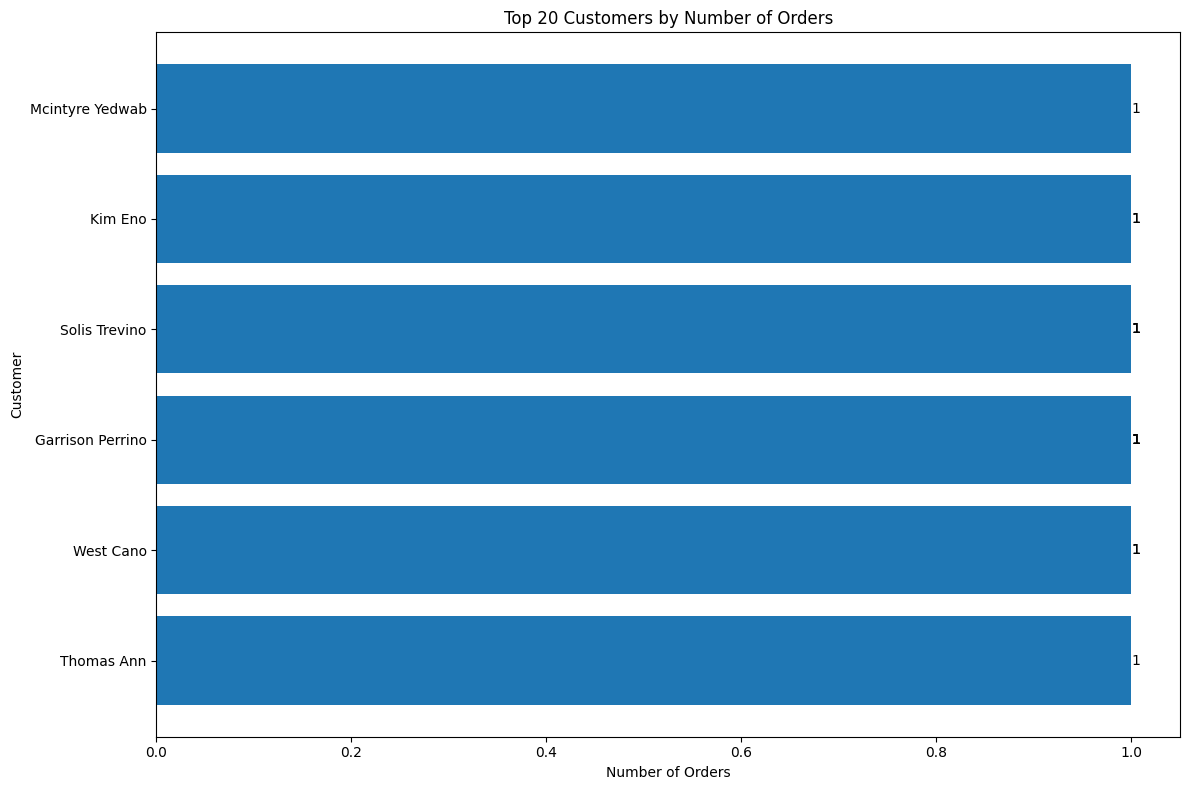

In [4]:
plt.figure(figsize=(12,8))

bars = plt.barh(
    top_customers.index.get_level_values("Customer Name"),
    top_customers["Total_Orders"]
)

plt.title("Top 20 Customers by Number of Orders")

plt.xlabel("Number of Orders")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y()+bar.get_height()/2,
        int(bar.get_width()),
        va="center"
    )

plt.tight_layout()

plt.savefig("../charts/top20_customer_orders.png", dpi=300)

plt.show()

In [5]:
top_aov = customer_summary.sort_values(
    by="Average_Order_Value",
    ascending=False
).head(20)

top_aov

,,Total_Orders,Total_Sales,Average_Order_Value
Customer ID,Customer Name,,,
ZO-00914,Fox D'Ascenzo,1,250.0,250.0
AN-007476,Hughes Brockman,1,250.0,250.0
AN-007491,Gay Willman,1,250.0,250.0
AN-007492,Haley Wasserman,1,250.0,250.0
AN-007499,Miranda Ryan,1,250.0,250.0
EY-003443,Carpenter Decherney,1,250.0,250.0
AN-007090,Smith Abelman,1,250.0,250.0
AN-007198,Edwards Beltran,1,250.0,250.0
AN-007243,Valentine Wasserman,1,250.0,250.0


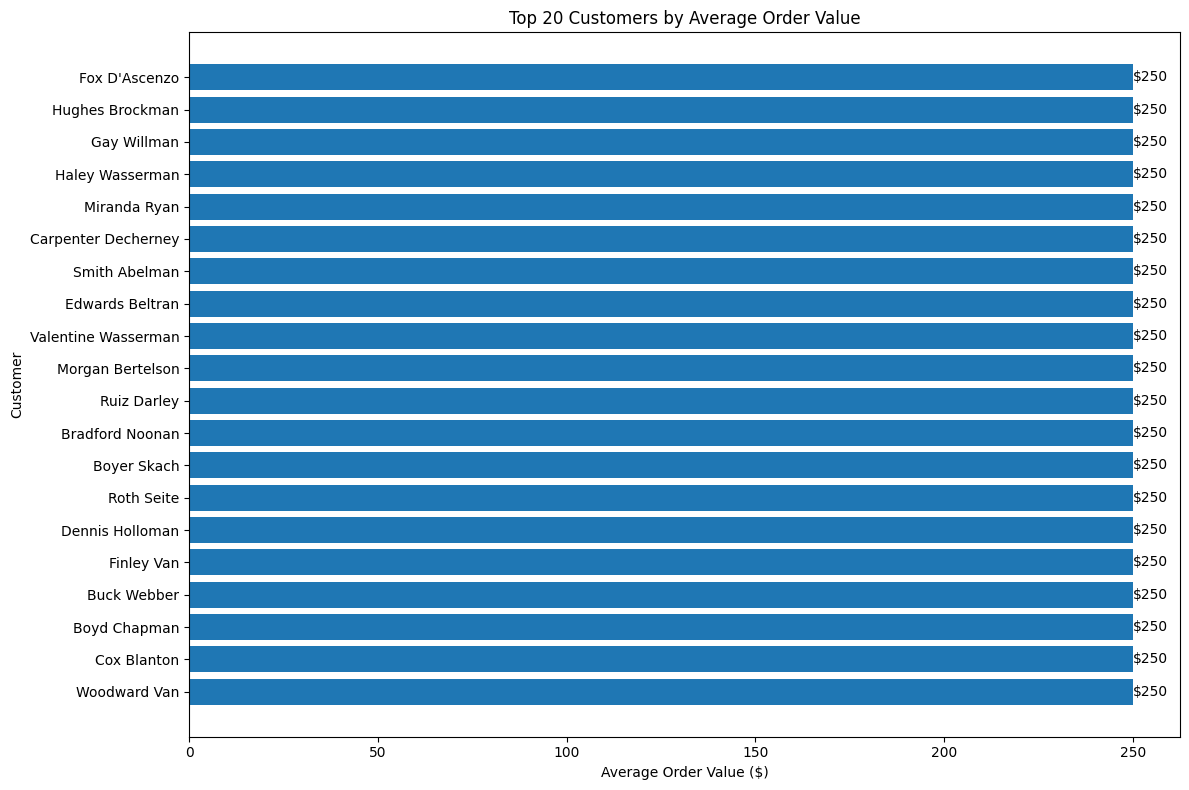

In [6]:
plt.figure(figsize=(12,8))

bars = plt.barh(
    top_aov.index.get_level_values("Customer Name"),
    top_aov["Average_Order_Value"]
)

plt.title("Top 20 Customers by Average Order Value")

plt.xlabel("Average Order Value ($)")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

for bar in bars:
    plt.text(
        bar.get_width(),
        bar.get_y()+bar.get_height()/2,
        f"${bar.get_width():.0f}",
        va="center"
    )

plt.tight_layout()

plt.savefig("../charts/top20_customer_aov.png", dpi=300)

plt.show()

In [7]:
repeat_customers = customer_summary[
    customer_summary["Total_Orders"] > 1
]

print("Total Repeat Customers :", len(repeat_customers))

repeat_customers.head()

Total Repeat Customers : 0


,,Total_Orders,Total_Sales,Average_Order_Value
Customer ID,Customer Name,,,


In [8]:
total_customers = len(customer_summary)

repeat_percentage = (
    len(repeat_customers) / total_customers
) * 100

print(f"Repeat Customer Percentage : {repeat_percentage:.2f}%")

Repeat Customer Percentage : 0.00%


## Business Insights

- Identified customers placing the highest number of orders.
- Calculated Average Order Value (AOV) for every customer.
- Measured the percentage of repeat customers.
- Repeat customers are valuable because they often contribute significantly to long-term revenue.

### Recommendations

- Reward repeat customers through loyalty programs.
- Identify high AOV customers for premium offers.
- Encourage first-time buyers to become repeat customers using personalized promotions.